<a href="https://colab.research.google.com/github/ruforavishnu/Project_Machine_Learning/blob/master/Project_22_Reinforcement_Learning_Autonomous_car_parking_using_Deep_Q_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install imageio

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.transforms as transforms
import imageio
import math
import random
from collections import deque



In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers



In [ ]:
plt.rcParams['figure.figsize'] = (6,6)
plt.rcParams['axes.facecolor'] = '#2E2E2E'

print('Tensorflow version: ', tf.__version__)
print('GPU available: ', tf.config.list_physical_devices('GPU'))



Tensorflow version:  2.19.0
GPU available:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
class ParkingEnv:

  def __init__(self):
    self.width = 10
    self.height = 10

    self.slot_x = 8
    self.slot_y = 5
    self.slot_width = 1.2
    self.slot_height = 2.0
    self.slot_angle = 0



    self.obstacles = [

                      (4,  4,  1,  1),
                      (4,  6,  1,  1)
    ]


    self.car_length = 0.8
    self.car_width = 0.4


    self.velocity = 0.15
    self.rotation_speed = 10 * np.pi / 180
    self.reset()

  def reset(self):
    self.x = np.random.uniform(1, 3)
    self.y = np.random.uniform(2, 8)
    self.theta = np.random.uniform(-np.pi,   np.pi)

    self.done = False
    self.steps = 0

    return self._get_state()


  def _get_state(self):

    dx = self.slot_x - self.x
    dy = self.slot_y - self.y
    distance = np.sqrt(  dx**2 + dy**2  )


    angle_diff = self.slot_angle - self.theta


    return np.array([ self.x / self.width , self.y / self.height , np.sin(self.theta) , np.cos(self.theta) , distance / np.sqrt(self.width**2 + self.height**2)],   dtype=np.float32)



  def step(self, action):
    """
        Actions:
        0 = Forward
        1 = Backward
        2 = Forward + Left
        3 = Forward + Right
        4 = Brake
    """

    if action == 0:
      self.x += self.velocity * np.cos(self.theta)
      self.y += self.velocity * np.sin(self.theta)


    elif action == 1:
      self.x -= self.velocity * np.cos(self.theta)
      self.y -= self.velocity * np.sin(self.theta)

    elif action == 2:
      self.theta += self.rotation_speed
      self.x += self.velocity * np.cos(self.theta)
      self.y += self.velocity * np.sin(self.theta)

    elif action == 3:
      self.theta -= self.rotation_speed
      self.x += self.velocity * np.cos(self.theta)
      self.y += self.velocity * np.sin(self.theta)


    elif action == 4:
      pass




    self.steps += 1


    # reward = -0.05
    reward  = -0.02

    dx = self.slot_x - self.x
    dy = self.slot_y - self.y
    distance = np.sqrt(  dx**2 + dy**2)

    # reward += -0.1 * distance
    reward += 1.0 / (distance + 0.1)



    if self.x < 0 or self.x > self.width or self.y < 0 or self.y > self.height:
      reward -= 100
      self.done = True


    for (ox,oy,ow,oh) in self.obstacles:
      if ox < self.x < ox + ow    and    oy < self.y < oy + oh:
        reward -= 100
        self.done = True


    if distance < 0.5 and abs(self.theta - self.slot_angle) < 10 * np.pi / 180:
      # reward = 100
      reward = 200
      self.done = True


    # if self.steps > 200:
    if self.steps > 100:
      self.done = True


    return self._get_state(),  reward,   self.done



  def render(self):
    fig, ax = plt.subplots()
    ax.set_xlim(0,  self.width)
    ax.set_ylim(0,  self.height)


    ax.set_facecolor('#2E2E2E')



    slot = patches.Rectangle(
        (self.slot_x  - self.slot_width / 2,
         self.slot_y - self.slot_height /2 ),
        self.slot_width,
        self.slot_height,
        linewidth = 2,
        edgecolor = '#3CB371',
        facecolor='none'
    )

    ax.add_patch(slot)



    for (ox, oy, ow, oh) in self.obstacles:
      obstacle = patches.Rectangle(
          (ox,oy) , ow, oh,
          color='#B22222'
      )

      ax.add_patch(obstacle)



    car = patches.Rectangle(
        (self.x - self.car_length/2,
         self.y -self.car_width/2),
        self.car_length,
        self.car_width,
        color='#1E90FF'
    )

    t = transforms.Affine2D().rotate_around(
        self.x, self.y, self.theta
    )  + ax.transData


    car.set_transform(t)
    ax.add_patch(car)




    plt.gca().set_aspect('equal',  adjustable='box')
    plt.xticks([])
    plt.yticks([])
    plt.show()















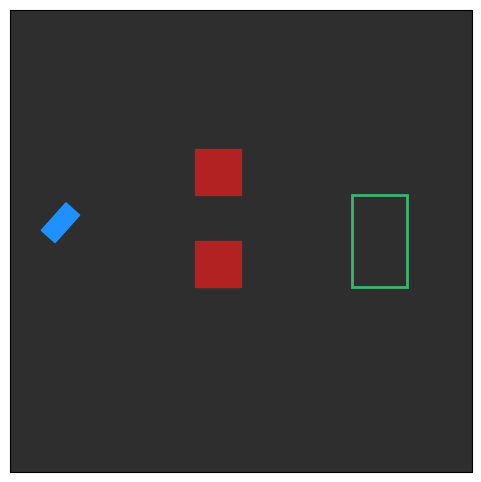

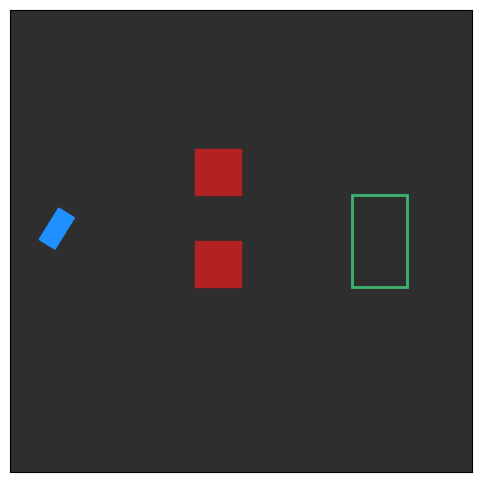

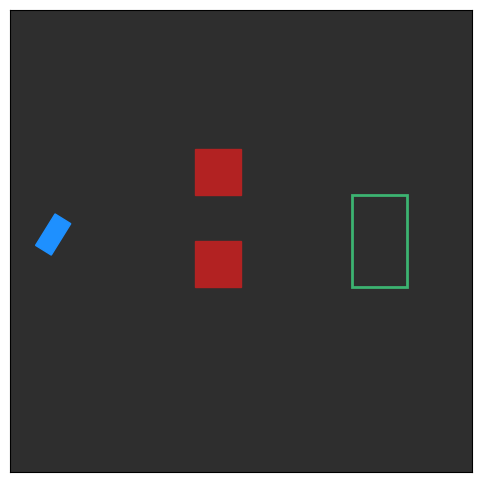

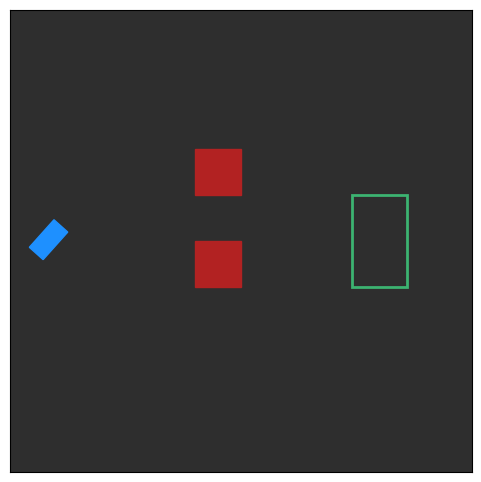

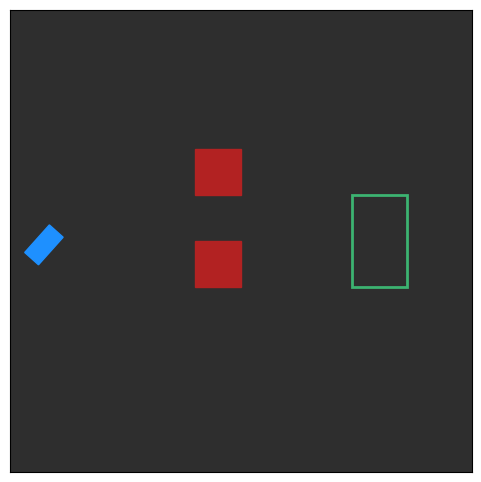

In [ ]:
env = ParkingEnv()
state = env.reset()


for _ in range(5):
  action = np.random.randint(0, 5)
  state, reward , done = env.step(action)
  env.render()


  if done:
    break




In [ ]:
class ReplayBuffer:

  def __init__(self, capacity=50_000):
    self.buffer = deque(maxlen=capacity)


  def add(self, state,  action, reward,  next_state, done):
    self.buffer.append( (state,action,reward, next_state, done))



  def sample(self, batch_size):
    batch = random.sample(self.buffer,   batch_size)


    states = np.array( [ b[0]  for b in batch ])
    actions = np.array( [ b[1]  for b in batch]  )
    rewards = np.array(  [  b[2]  for b in batch]  )
    next_states = np.array(  [  b[3]  for b in batch]  )
    dones = np.array(   [  b[4]   for b in batch  ])


    return states, actions, rewards, next_states, dones


  def __len__(self):
    return len(self.buffer)




In [ ]:
def build_dqn(state_size,   action_size  ):
  model = models.Sequential( [
      layers.Dense(128,   activation='relu',  input_shape=(state_size, )),
      layers.Dense(128,  activation='relu'),
      layers.Dense(action_size)


  ])


  return model



In [ ]:
class DQNAgent:


  def __init__(self, state_size, action_size):
    self.state_size = state_size
    self.action_size = action_size


    self.gamma = 0.99
    self.learning_rate = 0.001

    self.epsilon = 1.0
    self.epsilon_min = 0.05
    # self.epsilon_decay = 0.995
    self.epsilon_decay = 0.9995
    self.epsilon_min = 0.1

    self.batch_size = 64

    self.memory = ReplayBuffer()


    self.model = build_dqn(state_size,  action_size)
    self.target_model = build_dqn(state_size,  action_size)

    self.update_target()


    self.optimizer = optimizers.Adam(learning_rate=self.learning_rate)
    self.loss_fn = tf.keras.losses.Huber()

  def update_target(self):
    self.target_model.set_weights(self.model.get_weights())


  def act(self, state):
    if np.random.rand() < self.epsilon:
      return np.random.randint(self.action_size)

    state = np.expand_dims(state, axis=0)
    q_values = self.model(state,  training=False)
    return np.argmax(q_values[0])



  def train(self):
    if len(self.memory) < self.batch_size:
      return


    states, actions , rewards, next_states, dones = \
      self.memory.sample(self.batch_size)


    next_q = self.target_model(next_states)
    max_next_q = np.max(next_q,   axis=1)


    target_q = rewards + (  1 - dones ) * self.gamma * max_next_q


    with tf.GradientTape() as tape:
      q_values = self.model(states)
      q_action = tf.reduce_sum(
          q_values * tf.one_hot(actions, self.action_size),
          axis=1
      )

      loss = self.loss_fn(target_q ,  q_action)


    grads = tape.gradient(loss,   self.model.trainable_variables)
    self.optimizer.apply_gradients(  zip(grads, self.model.trainable_variables)   )


    # if self.epsilon > self.epsilon_min:
    #   self.epsilon *= self.epsilon_decay





In [ ]:
env = ParkingEnv()

state_size = 5
action_size = 5

agent = DQNAgent(state_size,   action_size)


print('Agent initialized succesfully')



Agent initialized succesfully


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
num_episodes = 1800
target_update_freq = 20


env = ParkingEnv()
state_size = 5
action_size = 5


agent = DQNAgent(state_size, action_size)


reward_history = []
checkpoints = {}


for episode in range(1,   num_episodes + 1):


  state = env.reset()
  total_reward = 0


  while True:
    action = agent.act(state)
    next_state, reward, done = env.step(action)

    agent.memory.add(state, action,  reward,  next_state,  done)
    agent.train()

    state = next_state
    total_reward += reward

    if done:
      break


  # Decay epsilon once per episode
  if agent.epsilon > agent.epsilon_min:
    agent.epsilon *= agent.epsilon_decay


  reward_history.append(total_reward)


  if episode % target_update_freq == 0:
    agent.update_target()




  if episode in [1, 300, 800, 1500, num_episodes]:
    checkpoints[episode] = agent.model.get_weights()

  if episode % 100 == 0:
    avg_reward = np.mean(reward_history[-100: ])
    print(f'Episode: {episode}  | Avg Reward (last 100) : {avg_reward:.2f}  | Epsilon : {agent.epsilon:.3f}')


print('Training complete.')

Episode: 100  | Avg Reward (last 100) : -62.06  | Epsilon : 0.951
Episode: 200  | Avg Reward (last 100) : -56.06  | Epsilon : 0.905
Episode: 300  | Avg Reward (last 100) : -60.30  | Epsilon : 0.861
Episode: 400  | Avg Reward (last 100) : -51.41  | Epsilon : 0.819
Episode: 500  | Avg Reward (last 100) : -50.55  | Epsilon : 0.779
Episode: 600  | Avg Reward (last 100) : -59.55  | Epsilon : 0.741
Episode: 700  | Avg Reward (last 100) : -54.27  | Epsilon : 0.705
Episode: 800  | Avg Reward (last 100) : -61.63  | Epsilon : 0.670
Episode: 900  | Avg Reward (last 100) : -49.82  | Epsilon : 0.638
Episode: 1000  | Avg Reward (last 100) : -51.92  | Epsilon : 0.606
Episode: 1100  | Avg Reward (last 100) : -62.56  | Epsilon : 0.577
Episode: 1200  | Avg Reward (last 100) : -48.91  | Epsilon : 0.549
Episode: 1300  | Avg Reward (last 100) : -48.78  | Epsilon : 0.522
Episode: 1400  | Avg Reward (last 100) : -57.27  | Epsilon : 0.496
Episode: 1500  | Avg Reward (last 100) : -49.43  | Epsilon : 0.472


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(reward_history)
plt.title("Training Reward Over Episodes")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.show()